In [2]:
# pip install PyWGCNA

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [98]:
# pip install --upgrade PyWGCNA

In [1]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA


In [3]:
# Cell 1 - imports and plotting backend
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import warnings; warnings.filterwarnings('ignore')
import PyWGCNA as pw
# import joblib; joblib.dump(w, 'w_good.joblib')
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams["figure.figsize"] = (8,6)

# import numpy as np, pandas as pd
# from sklearn.decomposition import PCA
# from scipy.stats import pearsonr
# import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
np.random.seed(42)

In [4]:
# Cell 2 - file paths and load
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA"   # << set this
expr_path = os.path.join(DATA_DIR, "tpm_expression.csv")
meta_path = os.path.join(DATA_DIR, "sample_info.csv")

expr = pd.read_csv(expr_path, index_col=0)   # genes x samples
meta = pd.read_csv(meta_path, index_col=0)   # samples x traits

# Ensure ordering and shapes
expr = expr[meta.index]
print("expr shape (genes x samples):", expr.shape)
print("meta shape:", meta.shape)
print("Missing in expr:", expr.isnull().sum().sum())
print("Missing in meta:", meta.isnull().sum().sum())
assert expr.shape[1] == meta.shape[0], "Sample mismatch!"

expr shape (genes x samples): (1692, 24)
meta shape: (24, 4)
Missing in expr: 0
Missing in meta: 0


In [5]:
# Cell 3 - filtering and transform
# Save originals if needed
expr_raw = expr.copy()

# Filter low expressed genes (TPM >= 1 in at least 3 samples)
keep = (expr >= 1).sum(axis=1) >= 3
expr_filt = expr.loc[keep]
print("After filter:", expr_filt.shape)

# Transform: log2(TPM + 1)
expr_log = np.log2(expr_filt + 1)
expr_log = expr_log[expr_log.var(axis=1) > 0.1]  # Adjustable threshold

After filter: (1685, 24)


Explained variance (%): [54.73 23.18  8.19]


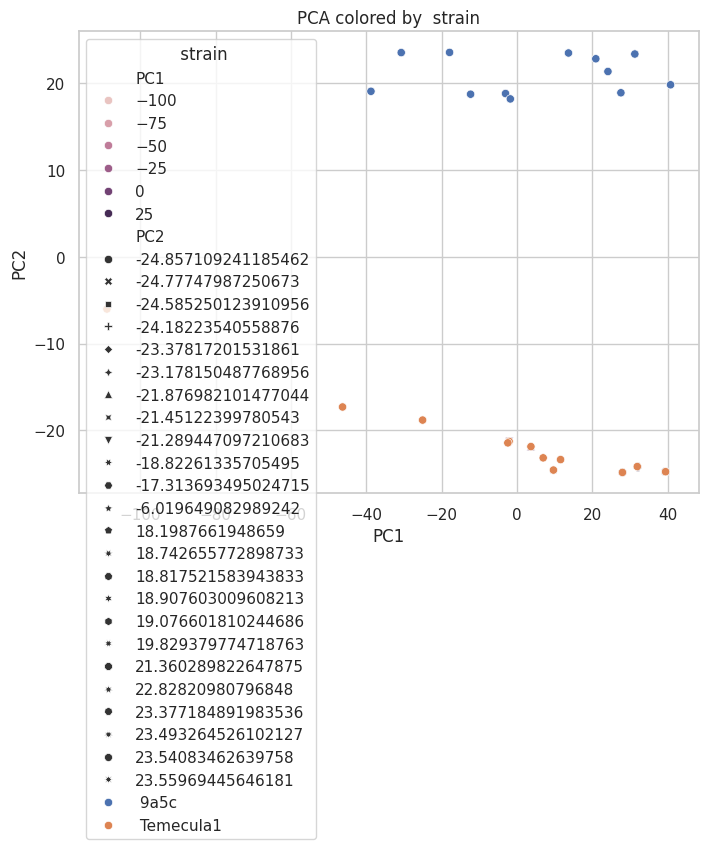

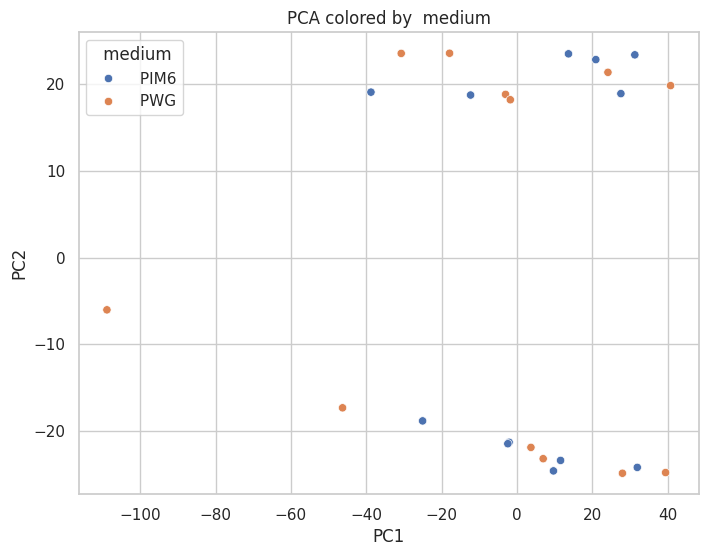

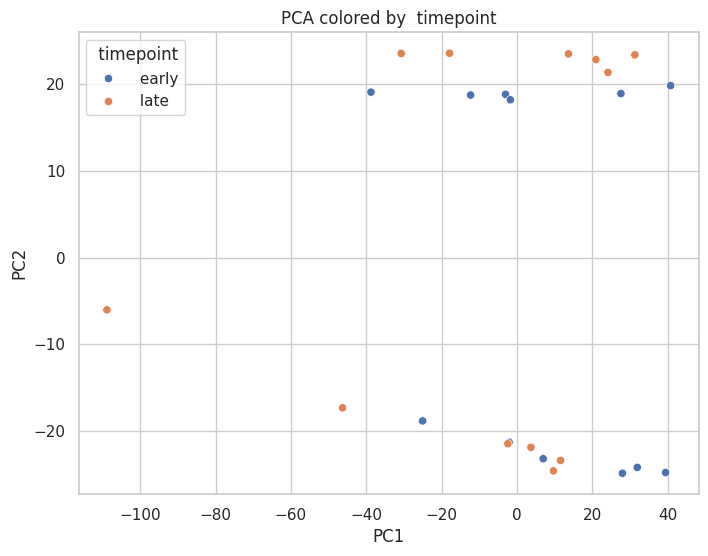

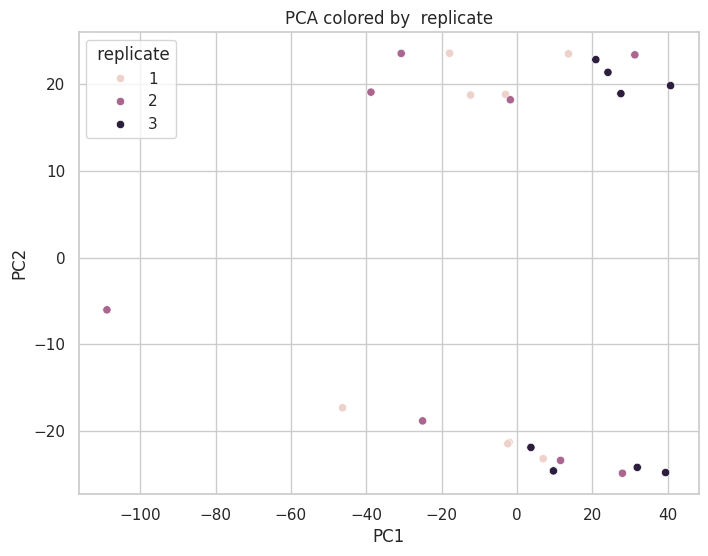

In [6]:
# Cell 4 - PCA for sample QC
X = expr_log.T  # samples x genes
pca = PCA(n_components=3)
pcs = pca.fit_transform(X.values)
pcs_df = pd.DataFrame(pcs, index=X.index, columns=['PC1','PC2','PC3'])
print("Explained variance (%):", (pca.explained_variance_ratio_*100).round(2))
# Combine with metadata and plot PC1 x PC2
plot_df = pd.concat([pcs_df, meta.loc[pcs_df.index]], axis=1)
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue=plot_df.columns[0], style=plot_df.columns[1] if plot_df.shape[1]>1 else None)
# sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='group', style='condition')  # Replace with your actual column names
# plt.title('PCA of samples'); plt.tight_layout(); plt.show()
for trait in meta.columns:
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue=trait)
    plt.title(f'PCA colored by {trait}'); plt.savefig(f'outputs/pca_by_{trait}.tiff', dpi=600, format='tiff', bbox_inches='tight'); plt.show()

WGCNA object created: Xf_WGCNA
expr shape: (24, 640)
pickSoftThreshold: calculating connectivity for given powers...
will use block size  640
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.917647  3.507188       0.909783  336.692423  352.249979   
1       1  0.917647  3.507188       0.909783  336.692423  352.249979   
2       2  0.849244  1.634445       0.908815  219.895226   229.36718   
3       3   0.67949  0.916171       0.759997  157.406539  163.814507   
4       3   0.67949  0.916171       0.759997  157.406539  163.814507   
5       4  0.497597  0.572588       0.653402  118.866581  121.657762   
6       5  0.320561  0.344159        0.61068   93.046461   93.908095   
7       5  0.320561  0.344159        0.61068   93.046461   93.908095   
8       6  0.133831  0.199697       0.522733    74.76485   74.229021   
9       7  0.011981  0.059234       0.489428   61.292267   59.286335   
10      7  0.011981  0.059234       0.489428   61.292267   59.2863

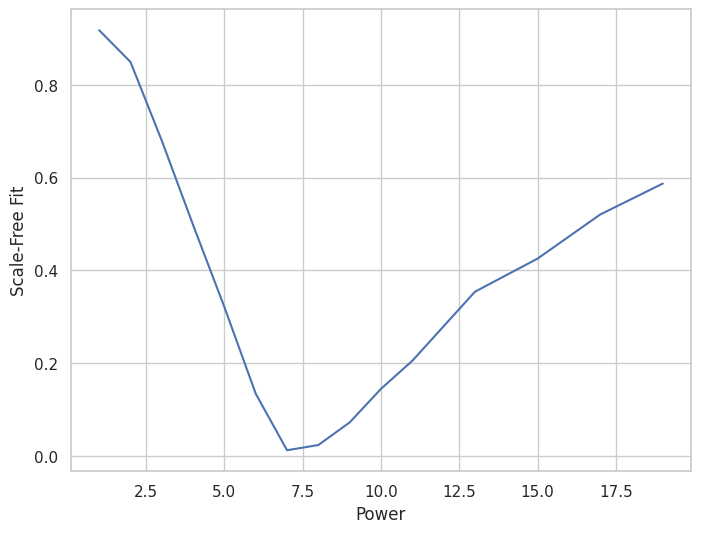

In [7]:
# Cell 5 - choose genes and create WGCNA object
# choose top variable genes (recommended)
top_n = 640   # try 1000-3000; smaller -> more chance to split
var_genes = expr_log.var(axis=1).sort_values(ascending=False)
genes_sel = var_genes.index[:top_n]
expr_for_wgcna = expr_log.loc[genes_sel].T   # samples x genes

# geneInfo with gene_id
geneInfo = pd.DataFrame(index=expr_for_wgcna.columns)
geneInfo['gene_id'] = geneInfo.index

# Create WGCNA object (level=1 single dataset)
w = pw.WGCNA(name="Xf_WGCNA", geneExp=expr_for_wgcna, sampleInfo=meta, geneInfo=geneInfo, level=1)

# set sensible default params (you can tweak after)
w.power = 20
w.networkType = 'signed'
w.TOMType = 'signed'
w.minModuleSize = 30
w.MEDissThres = 0.25

print("WGCNA object created:", w.name)
print("expr shape:", expr_for_wgcna.shape)

power_estimate, sft_df = w.pickSoftThreshold(data=expr_for_wgcna)  # Capture returns
w.sft = sft_df  # Optional: Set manually for later use
w.power = power_estimate  # Optional: Override with estimate (here 1); you had manually set 4
plt.plot(sft_df['Power'], sft_df['SFT.R.sq']); plt.xlabel('Power'); plt.ylabel('Scale-Free Fit'); plt.show()

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  640
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.881146   7.85325       0.876841  469.753714  487.304622   
1       2  0.889274  3.679675       0.907633  364.977521  385.307096   
2       3  0.865399  2.427613       0.908164   293.50878  312.220541   
3       4  0.847643  1.858664       0.930272  241.919798  256.988249   
4       5   0.80624  1.507234       0.927746  203.181826   214.05804   
5       6   0.73982  1.171791       0.914492  173.214409  182.266642   
6       7  0.672012  0.895511       0.883207  149.480153  157.519963   
7       8  0.609207  0.703616       0.878228  130.319068  136.862283   
8       9  0.532984   0.57426       0.866915  114.601237  118.875277   
9      10  0.423065  0.436046        0.81259  101.532425  104.781872   
10     11  0.291374  0.319125       0.722077   90.539218   92.941826   
11     13  0.126345  0.189174     

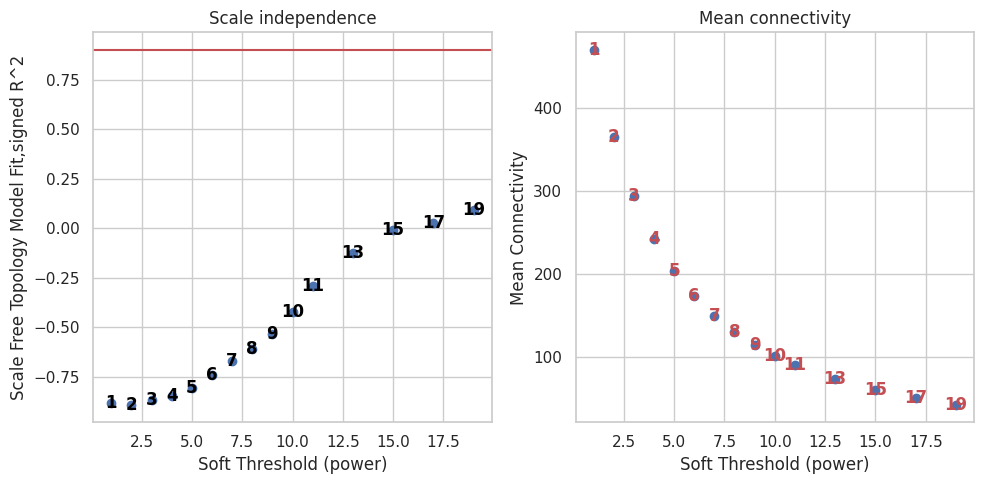

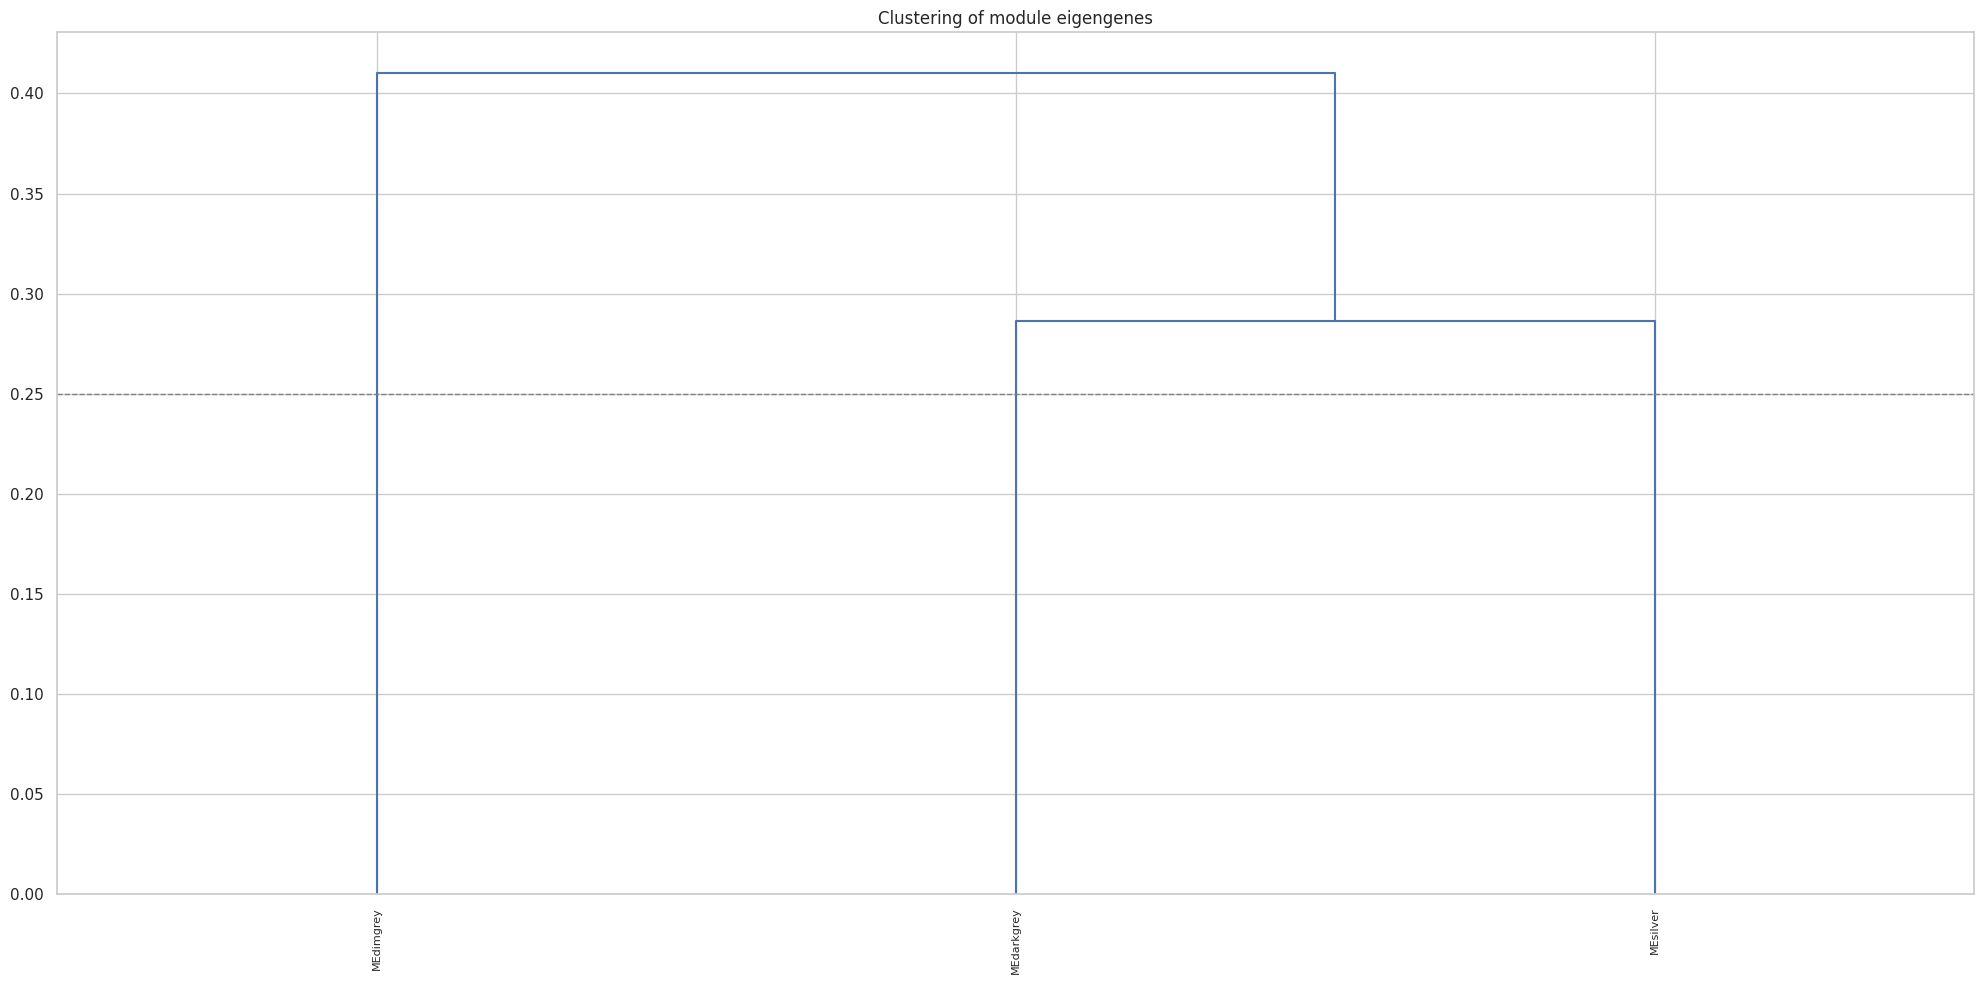

In [8]:
# Cell 6 - run module detection (safe kwargs)
kwargs = {'cutreeHybrid': {'deepSplit': 2, 'pamRespectsDendro': False}}
try:
    w.findModules(kwargs_function=kwargs)
    print("findModules finished.")
    print(w.sft)
except SystemExit as se:
    print("SystemExit from findModules:", se)
    print("Try adjusting w.power, w.minModuleSize, w.MEDissThres or top_n.")

datExpr.var cols: ['gene_id', 'dynamicColors', 'moduleColors', 'moduleLabels']
color_col: dynamicColors
color counts:
 dynamicColors
dimgrey     389
darkgrey    159
silver       92
Name: count, dtype: int64


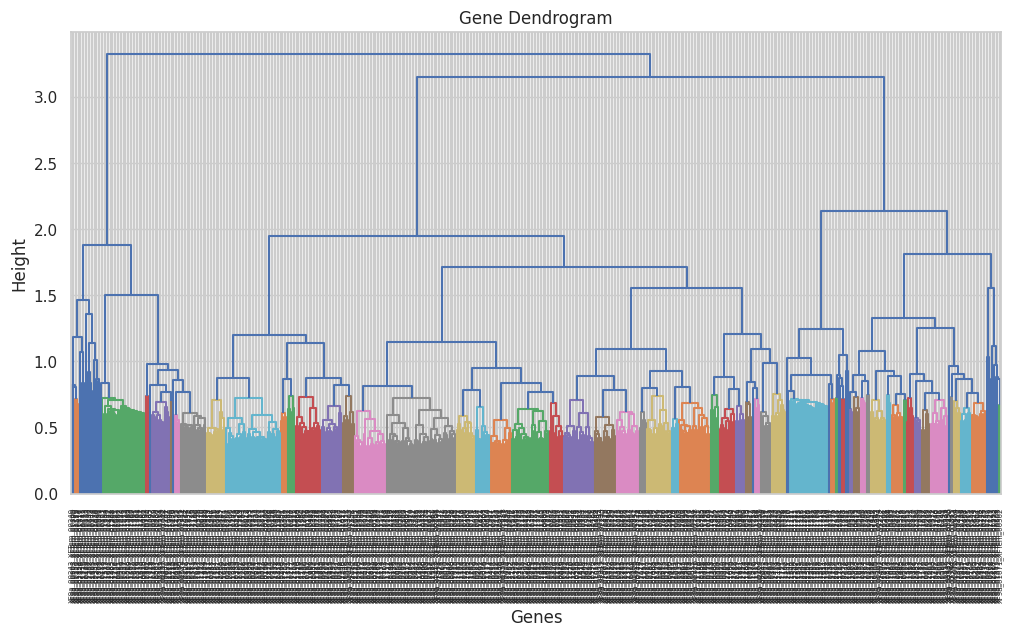

In [9]:
# Cell 7 - inspect datExpr.var for color column
print("datExpr.var cols:", list(w.datExpr.var.columns))
color_col = None
for c in ['dynamicColors','moduleColors','module_colors','dynamic_colors']:
    if c in w.datExpr.var.columns:
        color_col = c; break
print("color_col:", color_col)
print("color counts:\n", w.datExpr.var[color_col].value_counts())
import os
os.makedirs('outputs', exist_ok=True)
w.datExpr.var[color_col].value_counts().to_csv('outputs/module_color_counts.csv')

# Compute dissimilarity TOM (dissTOM = 1 - TOM); w.TOM should be genes x genes
dissTOM = 1 - w.TOM.to_numpy()  # Convert to NumPy if needed; handle any NaNs
np.fill_diagonal(dissTOM, 0)  # Ensure diagonal is 0

# Hierarchical clustering
Z = linkage(dissTOM, method='average')  # 'average' is common for WGCNA

# Plot dendrogram with module colors
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=w.datExpr.var.index, leaf_rotation=90, color_threshold=1 - w.MEDissThres)
# Optionally add module color bars below (manual: map colors to leaves)
plt.title('Gene Dendrogram'); plt.xlabel('Genes'); plt.ylabel('Height'); plt.savefig('outputs/dendogram.tiff', dpi=600, format='tiff', bbox_inches='tight'); plt.show()

In [43]:
# # Cell 8 - optionally run the grid-retry script (only if single module)
# # (Use the B automatic block from earlier if you need to re-search parameters)
# # B: robust re-run attempts (try multiple parameter combos automatically)
# import itertools, pandas as pd, numpy as np

# # choose gene set: try top 3000, 2000, 1000 (will try smaller sets if collapse continues)
# var_sorted = expr_log.var(axis=1).sort_values(ascending=False)
# try_topn = [3000, 2000, 1000]

# # parameter grid to try
# powers = [6, 8, 12]                  # candidate soft powers
# network_types = ['signed', 'unsigned']
# TOM_types = ['signed', 'unsigned']
# deepSplits = [2, 3, 4]               # more aggressive splitting
# MEDissTries = [0.12, 0.08, 0.05]     # lower = less merging

# successful = None

# for topn in try_topn:
#     genes_sel = var_sorted.index[:topn]
#     expr_try = expr_log.loc[genes_sel].T   # samples x genes
#     print("\nTrying top_n =", topn, "genes:", expr_try.shape)
#     # build geneInfo
#     geneInfo = pd.DataFrame(index=expr_try.columns)
#     geneInfo['gene_id'] = geneInfo.index

#     # try parameter combinations
#     for power, net, tom, ds, med in itertools.product(powers, network_types, TOM_types, deepSplits, MEDissTries):
#         print(f"\nAttempt: topn={topn}, power={power}, net={net}, tom={tom}, deepSplit={ds}, MEDiss={med}")
#         w2 = pw.WGCNA(name=f"w2_top{topn}_p{power}_{net}_{tom}_ds{ds}_med{med}",
#                       geneExp=expr_try, sampleInfo=meta, geneInfo=geneInfo, level=1)
#         # set parameters
#         w2.power = power
#         w2.networkType = net
#         w2.TOMType = tom
#         w2.minModuleSize = 15 if topn <= 2000 else 20
#         w2.MEDissThres = med
#         # run findModules (use kwargs_function)
#         kwargs_function = {'cutreeHybrid': {'deepSplit': ds, 'pamRespectsDendro': False}}
#         try:
#             w2.findModules(kwargs_function=kwargs_function)
#         except SystemExit as se:
#             print("SystemExit -> likely all genes in one module. Continuing.")
#             continue
#         except Exception as e:
#             print("Exception during findModules:", repr(e)); continue

#         # if we reach here, try extracting module colors
#         dfv2 = w2.datExpr.var
#         color_col = None
#         for col in ['dynamicColors', 'moduleColors', 'dynamic_colors', 'colors']:
#             if col in dfv2.columns:
#                 color_col = col; break
#         if color_col is None:
#             print("No color column in w2.datExpr.var; continuing.")
#             continue

#         nmods = dfv2[color_col].nunique()
#         print("nmods found:", nmods, "color_col:", color_col)
#         if nmods > 1:
#             print("SUCCESS with parameters:", topn, power, net, tom, ds, med)
#             successful = (w2, topn, power, net, tom, ds, med, color_col)
#             break
#     if successful:
#         break

# if successful is None:
#     raise RuntimeError("All attempts failed to produce >1 module. Consider inspecting global correlation structure (PCA) or reducing data further.")
# else:
#     w_good, topn, power, net, tom, ds, med, color_col = successful
#     print("Using w_good:", w_good.name)
#     print("module color column in datExpr.var:", color_col)
#     # export module gene lists
#     dfv = w_good.datExpr.var
#     mods = {c: list(g.index) for c,g in dfv.groupby(color_col)}
#     for col, gl in mods.items():
#         pd.Series(gl).to_csv(f"wgood_module_{col}_genes.txt", index=False, header=False)
#     print("Exported module gene lists for successful run.")
# if successful:
#     w = w_good  # Override original w with successful one
#     print("Overrode w with successful w_good.")

datExpr.var columns: ['gene_id', 'dynamicColors', 'moduleColors', 'moduleLabels']
Module color counts:
 dynamicColors
dimgrey     389
darkgrey    159
silver       92
Name: count, dtype: int64
expr_mat shape (samples x genes): (24, 640)
Module eigengenes computed. MEs shape: (24, 3)


,MEdimgrey,MEdarkgrey,MEsilver
sampleID,,,
9a_PIM6_1d_1,2.878490,-13.248088,2.970656
9a_PIM6_1d_2,-9.514185,-19.902278,-5.832549
9a_PIM6_1d_3,23.183734,-2.217254,8.911840
9a_PIM6_3d_1,19.953696,-7.888947,-7.823459
9a_PIM6_3d_2,27.894665,-3.881425,-5.426281


Module-trait correlation (sample):


,replicate,strain_ 9a5c,strain_ Temecula1,medium_ PIM6,medium_ PWG,timepoint_ early,timepoint_ late
MEdimgrey,0.340,0.641,-0.641,0.161,-0.161,0.125,-0.125
MEdarkgrey,0.303,-0.676,0.676,0.143,-0.143,0.196,-0.196
MEsilver,0.254,-0.031,0.031,-0.023,0.023,0.674,-0.674


Module-trait correlation (sample):


,replicate,strain_ 9a5c,strain_ Temecula1,medium_ PIM6,medium_ PWG,timepoint_ early,timepoint_ late
MEdimgrey,0.340,0.641,-0.641,0.161,-0.161,0.125,-0.125
MEdarkgrey,0.303,-0.676,0.676,0.143,-0.143,0.196,-0.196
MEsilver,0.254,-0.031,0.031,-0.023,0.023,0.674,-0.674


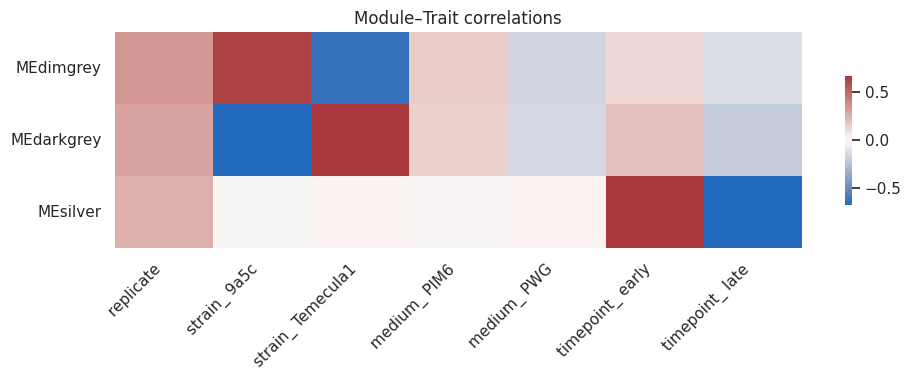

Top 10 hubs in dimgrey: ['XF9a_00077_XFTem_00071', 'XF9a_02526_XFTem_02363', 'XF9a_00531_XFTem_01804', 'XF9a_00252_XFTem_00251', 'XF9a_02306_XFTem_01693', 'XF9a_00611_XFTem_01734', 'XF9a_02132_XFTem_01499', 'XF9a_01738_XFTem_01082', 'XF9a_02187_XFTem_01550', 'XF9a_00523_XFTem_01811']
Top 10 hubs in darkgrey: ['XF9a_02603_XFTem_02437', 'XF9a_01315_XFTem_00749', 'XF9a_00432_XFTem_01246', 'XF9a_02521_XFTem_02357', 'XF9a_02262_XFTem_01638', 'XF9a_02028_XFTem_01394', 'XF9a_02566_XFTem_02405', 'XF9a_01001_XFTem_00408', 'XF9a_00699_XFTem_02198', 'XF9a_00160_XFTem_00153']
Top 10 hubs in silver: ['XF9a_00094_XFTem_00088', 'XF9a_02483_XFTem_02318', 'XF9a_02299_XFTem_01686', 'XF9a_02487_XFTem_02322', 'XF9a_00419_XFTem_01874', 'XF9a_00095_XFTem_00089', 'XF9a_00285_XFTem_00284', 'XF9a_02427_XFTem_02259', 'XF9a_00749_XFTem_02148', 'XF9a_01059_XFTem_00490']
Exported module gene lists and hub files.


In [10]:
# Cell 9 - postprocessing (compute MEs manually from dynamicColors, module-trait heatmap, hub genes)
# Reuse the robust A-block code from my previous message (computes MEs via PCA per module)
# Copy-paste the A code block here. It will create:
#   - module_<color>_genes.txt
#   - module_<color>_top10_hubs.txt
#   - and will show module-trait heatmap
# A: extract modules, compute MEs manually, module-trait heatmap, hubs
# 1) check module assignments in datExpr.var (use dynamicColors)
dfvar = w.datExpr.var
print("datExpr.var columns:", list(dfvar.columns))
if 'dynamicColors' in dfvar.columns:
    colors = dfvar['dynamicColors']
else:
    raise RuntimeError("No 'dynamicColors' in datExpr.var; check your w object.")

print("Module color counts:\n", colors.value_counts())

# If only one color present, print a message and exit A
if colors.nunique() <= 1:
    print("Only one module detected (color):", colors.unique())
    print("Skip A and run the re-run recipe in B.")
else:
    # 2) expression matrix (samples x genes)
    expr_mat = pd.DataFrame(w.geneExpr.X, index=w.geneExpr.obs.index, columns=w.geneExpr.var.index)
    print("expr_mat shape (samples x genes):", expr_mat.shape)

    # 3) compute Module Eigengenes (first PC) per color
    ME_df = pd.DataFrame(index=expr_mat.index)
    module_genes = {}
    for col in colors.unique():
        genes = list(dfvar.loc[dfvar['dynamicColors'] == col].index)
        module_genes[col] = genes
        # subset expression: samples x genes_in_module
        Xsub = expr_mat[genes].copy()
        # center genes (subtract gene means across samples) before PCA
        Xc = Xsub - Xsub.mean(axis=0)
        # if module has 1 gene, the "eigengene" is that gene's (centered) expression
        if Xc.shape[1] == 1:
            me = Xc.iloc[:,0]
        else:
            pca = PCA(n_components=1)
            me = pca.fit_transform(Xc.values)[:,0]
            me = pd.Series(me, index=Xc.index)
        ME_df["ME" + col] = me

    print("Module eigengenes computed. MEs shape:", ME_df.shape)
    display(ME_df.head())

    # 4) prepare traits (dummy encode categorical)
    traits = meta.copy()
    for c in traits.columns:
        if traits[c].dtype == object or str(traits[c].dtype).startswith('category'):
            d = pd.get_dummies(traits[c], prefix=c)
            traits = traits.drop(columns=c).join(d)
    # align sample order
    traits = traits.loc[ME_df.index]

    # 5) compute correlations and p-values
    me_cols = ME_df.columns.tolist()
    trait_cols = traits.columns.tolist()
    corr_df = pd.DataFrame(index=me_cols, columns=trait_cols, dtype=float)
    pval_df = pd.DataFrame(index=me_cols, columns=trait_cols, dtype=float)
    for m in me_cols:
        for t in trait_cols:
            r, p = pearsonr(ME_df[m], traits[t])
            corr_df.loc[m, t] = r
            pval_df.loc[m, t] = p

    print("Module-trait correlation (sample):")
    display(corr_df.round(3))

    # 6) plot heatmap
    # plt.figure(figsize=(max(6, 0.6*len(trait_cols)), max(6, 0.4*len(me_cols))))
    # ax = sns.heatmap(corr_df.astype(float), center=0, cmap="vlag", annot=corr_df.round(3), fmt=".3f")
    # ax.set_title("Module–Trait correlations")
    # plt.tight_layout()
    # plt.show()

    # Annot with corr and * for sig (p<0.05)
    # annot = corr_df.round(3).astype(str)
    # for m in me_cols:
    #     for t in trait_cols:
    #         if pval_df.loc[m, t] < 0.05:
    #             annot.loc[m, t] += '*'
    # ax = sns.heatmap(corr_df.astype(float), center=0, cmap="vlag", annot=annot, fmt="")

    # Handle dummy encoding categorical traits
    traits = meta.copy()
    for c in traits.columns:
        if traits[c].dtype == object or str(traits[c].dtype).startswith('category'):
            d = pd.get_dummies(traits[c], prefix=c)
            traits = traits.drop(columns=c).join(d)
    
    # Align sample order
    traits = traits.loc[ME_df.index]
    
    # Compute correlations and p-values
    me_cols = ME_df.columns.tolist()
    trait_cols = traits.columns.tolist()
    corr_df = pd.DataFrame(index=me_cols, columns=trait_cols, dtype=float)
    pval_df = pd.DataFrame(index=me_cols, columns=trait_cols, dtype=float)
    for m in me_cols:
        for t in trait_cols:
            r, p = pearsonr(ME_df[m], traits[t])
            corr_df.loc[m, t] = r
            pval_df.loc[m, t] = p
    
    print("Module-trait correlation (sample):")
    display(corr_df.round(3))
    
    # Plot heatmap with modifications
    fig, ax = plt.subplots(figsize=(10, 4))  # Adjusted for squarer cells (wider figure for 7 cols, shorter for 3 rows)
    sns.heatmap(
        corr_df.astype(float), 
        center=0, 
        cmap="vlag", 
        annot=False,  # Remove numbers
        ax=ax,
        cbar_kws={'shrink': 0.6}  # Shrink colorbar height to ~1/3
    )
    ax.set_title("Module–Trait correlations")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Horizontal y-labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # 45° x-labels
    plt.tight_layout()
    # Save heatmap (after plt.show())
    plt.savefig('outputs/module_trait_heatmap.tiff', dpi=600, format='tiff', bbox_inches='tight')
    plt.show()

    # 7) compute kME (module membership): cor(gene, module eigengene)
    kME = pd.DataFrame(index=expr_mat.columns)
    for m in me_cols:
        kME[m] = expr_mat.corrwith(ME_df[m])
    # export top hubs per module
    topN = 10
    hubs = {}
    for col, genes in module_genes.items():
        me_name = "ME" + col
        if me_name not in kME.columns:
            print("ME column missing:", me_name); continue
        km = kME.loc[genes, me_name].sort_values(ascending=False)
        hubs[col] = km.head(topN).index.tolist()
        print(f"Top {topN} hubs in {col}:", hubs[col])
        pd.Series(hubs[col]).to_csv(f"module_{col}_top{topN}_hubs.txt", index=False, header=False)

    # export module gene lists
    for col, genes in module_genes.items():
        pd.Series(genes).to_csv(f"module_{col}_genes.txt", index=False, header=False)
    print("Exported module gene lists and hub files.")

# After module_genes/hubs
for col, genes in module_genes.items():
    pd.Series(genes).to_csv(f'outputs/module_{col}_genes.txt', index=False, header=False)
for col, hub_list in hubs.items():
    pd.Series(hub_list).to_csv(f'outputs/module_{col}_top10_hubs.txt', index=False, header=False)
corr_df.to_csv('outputs/module_trait_correlations.csv')
pval_df.to_csv('outputs/module_trait_pvalues.csv')

In [11]:
# Cell 10 - save selected outputs and object (if you want)
import pickle
with open('outputs/wgcna_object.pkl', 'wb') as f:
    pickle.dump(w, f)
expr_log.to_csv('outputs/expr_log.csv')
meta.to_csv('outputs/meta.csv')
ME_df.to_csv('outputs/module_eigengenes.csv')

Explained: PC1 54.7%, PC2 23.2%, PC3 8.2%, PC4 2.9%
Available meta columns: [' strain', ' medium', ' timepoint', ' replicate']


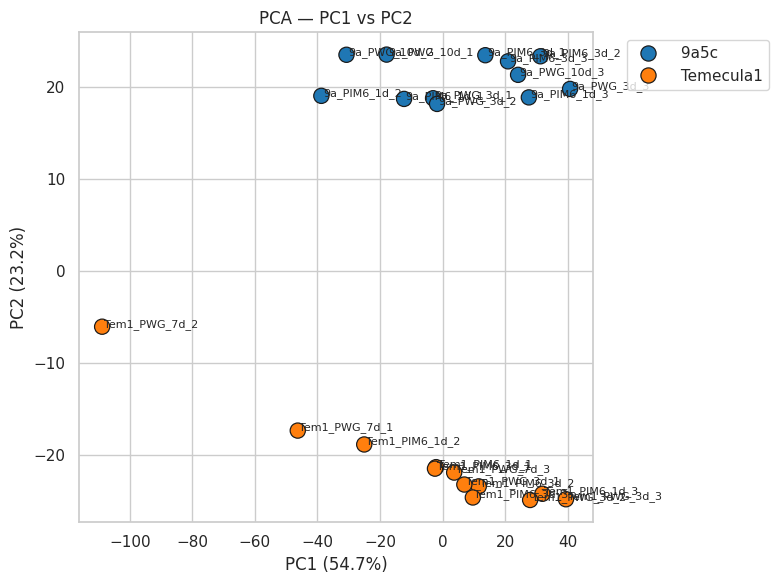

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
sns.set(style="whitegrid")

# expr_log: genes x samples (log2(TPM+1)) from pipeline
X = expr_log.T  # samples x genes
pca = PCA(n_components=4)
pcs = pca.fit_transform(X.values)
pcs_df = pd.DataFrame(pcs, index=X.index, columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
explained = pca.explained_variance_ratio_ * 100
print(f"Explained: PC1 {explained[0]:.1f}%, PC2 {explained[1]:.1f}%, PC3 {explained[2]:.1f}%, PC4 {explained[3]:.1f}%")

# Combine with metadata
plot_df = pd.concat([pcs_df, meta.loc[pcs_df.index]], axis=1)

# Customize: Use your actual meta columns (e.g., 'strain', 'medium', 'timepoint')
color_by = "strain"  # e.g., "strain" for 9a5c vs Temecula1
shape_by = "medium"  # e.g., "medium" for PIM6 vs PWG; set to None if not needed

# Fallback if columns missing
available_cols = list(meta.columns)
print("Available meta columns:", available_cols)
if color_by not in plot_df.columns:
    color_by = available_cols[0] if available_cols else None
if shape_by not in plot_df.columns:
    shape_by = None

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=color_by, style=shape_by, s=120, palette="tab10", edgecolor="k")
plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
plt.title("PCA — PC1 vs PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Optional: Label points (uncomment if samples are few; can clutter)
for i, s in plot_df.iterrows():
    plt.text(s["PC1"] + 0.5, s["PC2"], i, fontsize=8)
# After each plt.show()
plt.savefig(f'outputs/pca_by_{trait}.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

Original Meta columns: [' strain', ' medium', ' timepoint', ' replicate']

Original Meta head:
              strain medium timepoint  replicate
sampleID                                       
9a_PIM6_1d_1   9a5c   PIM6     early          1
9a_PIM6_1d_2   9a5c   PIM6     early          2
9a_PIM6_1d_3   9a5c   PIM6     early          3
9a_PIM6_3d_1   9a5c   PIM6      late          1
9a_PIM6_3d_2   9a5c   PIM6      late          2

Stripped Meta columns: ['strain', 'medium', 'timepoint', 'replicate']

Stripped Meta head:
              strain medium timepoint  replicate
sampleID                                       
9a_PIM6_1d_1   9a5c   PIM6     early          1
9a_PIM6_1d_2   9a5c   PIM6     early          2
9a_PIM6_1d_3   9a5c   PIM6     early          3
9a_PIM6_3d_1   9a5c   PIM6      late          1
9a_PIM6_3d_2   9a5c   PIM6      late          2


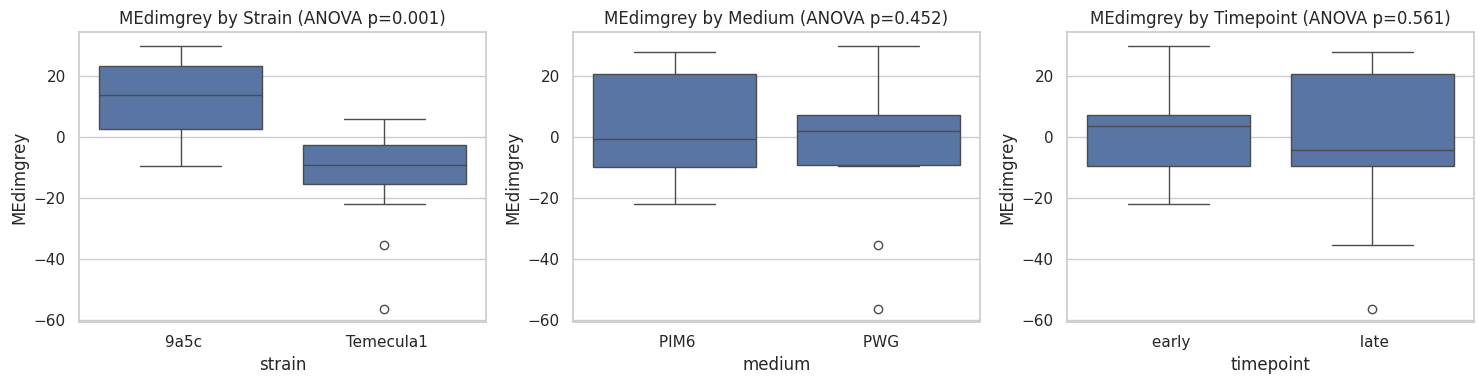

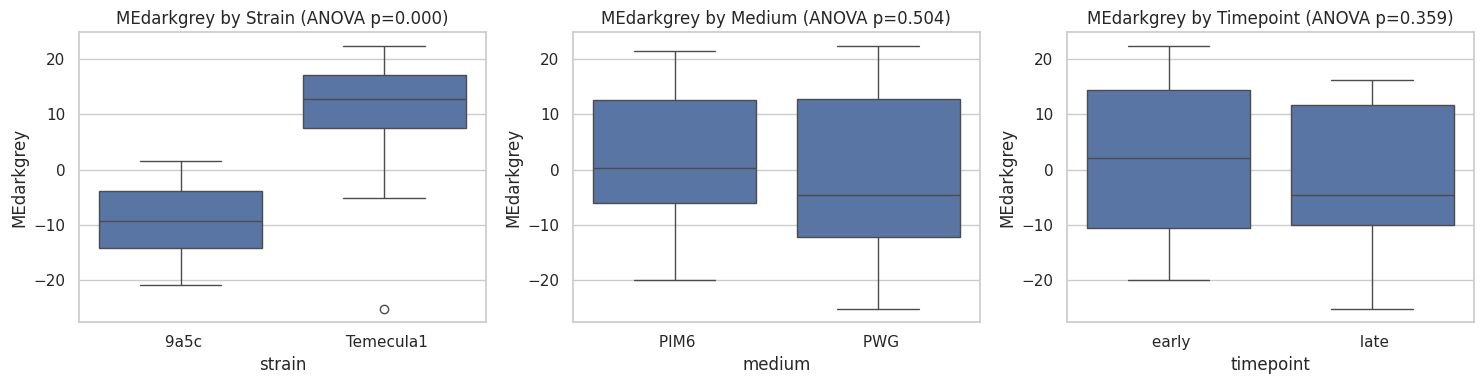

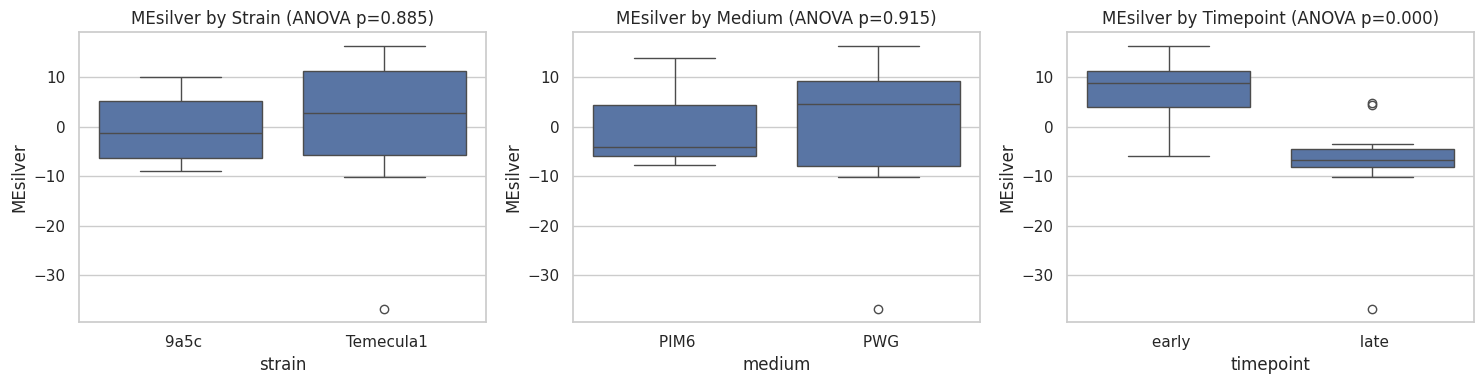

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway  # For ANOVA p-values

# Diagnostics: Print to inspect
print("Original Meta columns:", list(meta.columns))
print("\nOriginal Meta head:\n", meta.head())

# Strip leading/trailing spaces from column names
meta.columns = meta.columns.str.strip()

print("\nStripped Meta columns:", list(meta.columns))
print("\nStripped Meta head:\n", meta.head())

# Check if key columns missing (after strip)
if 'strain' not in meta.columns or 'medium' not in meta.columns or 'timepoint' not in meta.columns:
    print("Parsing missing columns from sample index...")
    # Use to_series() to ensure DataFrame output
    parsed = meta.index.to_series().str.split('_', expand=True)
    meta['strain'] = parsed[0].map({'9a': '9a5c', 'Tem': 'Temecula1'})  # Adjust mapping if needed
    meta['medium'] = parsed[1]  # e.g., 'PIM6' or 'PWG'
    meta['timepoint'] = parsed[2].map({'1d': 'early', '3d': 'early', '7d': 'late', '10d': 'late'})  # Adjust based on phases
    # Replicate: If missing, add from parsed[3]
    if 'replicate' not in meta.columns:
        meta['replicate'] = parsed[3].astype(int)  # Assume numeric

# Now plot
for me_col in ME_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # By strain
    sns.boxplot(x=meta.loc[ME_df.index, 'strain'], y=ME_df[me_col], ax=axes[0])
    groups_strain = [ME_df[me_col][meta['strain'] == g] for g in meta['strain'].unique() if len(ME_df[me_col][meta['strain'] == g]) > 0]
    if len(groups_strain) > 1:
        p_strain = f_oneway(*groups_strain).pvalue
        axes[0].set_title(f"{me_col} by Strain (ANOVA p={p_strain:.3f})")
    else:
        axes[0].set_title(f"{me_col} by Strain")
    
    # By medium
    sns.boxplot(x=meta.loc[ME_df.index, 'medium'], y=ME_df[me_col], ax=axes[1])
    groups_medium = [ME_df[me_col][meta['medium'] == g] for g in meta['medium'].unique() if len(ME_df[me_col][meta['medium'] == g]) > 0]
    if len(groups_medium) > 1:
        p_medium = f_oneway(*groups_medium).pvalue
        axes[1].set_title(f"{me_col} by Medium (ANOVA p={p_medium:.3f})")
    else:
        axes[1].set_title(f"{me_col} by Medium")
    
    # By timepoint
    sns.boxplot(x=meta.loc[ME_df.index, 'timepoint'], y=ME_df[me_col], ax=axes[2])
    groups_time = [ME_df[me_col][meta['timepoint'] == g] for g in meta['timepoint'].unique() if len(ME_df[me_col][meta['timepoint'] == g]) > 0]
    if len(groups_time) > 1:
        p_time = f_oneway(*groups_time).pvalue
        axes[2].set_title(f"{me_col} by Timepoint (ANOVA p={p_time:.3f})")
    else:
        axes[2].set_title(f"{me_col} by Timepoint")
    
    plt.tight_layout()
    # After plt.show() in loop
    plt.savefig(f'outputs/boxplots_{me_col}.png', dpi=600, format='tiff', bbox_inches='tight')
    plt.show()
    

In [14]:
import pandas as pd
from scipy.stats import chi2_contingency  # Optional: Test independence

# Diagnostics
print("Original Meta columns:", list(meta.columns))
print("\nOriginal Meta head:\n", meta.head())

# Strip spaces from column names
meta.columns = meta.columns.str.strip()

print("\nStripped Meta columns:", list(meta.columns))
print("\nStripped Meta head:\n", meta.head())

# Parse if missing (optional, uncomment if needed)
# if 'strain' not in meta.columns or 'medium' not in meta.columns or 'timepoint' not in meta.columns:
#     print("Parsing missing columns from sample index...")
#     parsed = meta.index.to_series().str.split('_', expand=True)
#     meta['strain'] = parsed[0].map({'9a': '9a5c', 'Tem': 'Temecula1'})
#     meta['medium'] = parsed[1]
#     meta['timepoint'] = parsed[2].map({'1d': 'early', '3d': 'early', '7d': 'late', '10d': 'late'})

# Crosstabs
print("\nStrain x Medium:\n", pd.crosstab(meta['strain'], meta['medium']))
print("\nStrain x Timepoint:\n", pd.crosstab(meta['strain'], meta['timepoint']))
print("\nMedium x Timepoint:\n", pd.crosstab(meta['medium'], meta['timepoint']))

# Optional Chi-square for each pair
for pair in [('strain', 'medium'), ('strain', 'timepoint'), ('medium', 'timepoint')]:
    if pair[0] in meta.columns and pair[1] in meta.columns:
        crosstab = pd.crosstab(meta[pair[0]], meta[pair[1]])
        if crosstab.size > 0 and crosstab.shape[0] > 0 and crosstab.shape[1] > 0:
            chi2, p, dof, expected = chi2_contingency(crosstab)
            print(f"\nChi-square ({pair[0]} x {pair[1]}): chi2={chi2:.2f}, p={p:.4f}")
        else:
            print(f"\nNo data for Chi-square ({pair[0]} x {pair[1]})")

Original Meta columns: ['strain', 'medium', 'timepoint', 'replicate']

Original Meta head:
              strain medium timepoint  replicate
sampleID                                       
9a_PIM6_1d_1   9a5c   PIM6     early          1
9a_PIM6_1d_2   9a5c   PIM6     early          2
9a_PIM6_1d_3   9a5c   PIM6     early          3
9a_PIM6_3d_1   9a5c   PIM6      late          1
9a_PIM6_3d_2   9a5c   PIM6      late          2

Stripped Meta columns: ['strain', 'medium', 'timepoint', 'replicate']

Stripped Meta head:
              strain medium timepoint  replicate
sampleID                                       
9a_PIM6_1d_1   9a5c   PIM6     early          1
9a_PIM6_1d_2   9a5c   PIM6     early          2
9a_PIM6_1d_3   9a5c   PIM6     early          3
9a_PIM6_3d_1   9a5c   PIM6      late          1
9a_PIM6_3d_2   9a5c   PIM6      late          2

Strain x Medium:
 medium     PIM6  PWG
strain              
9a5c          6    6
Temecula1     6    6

Strain x Timepoint:
 timepoint  early  

In [15]:
import pandas as pd
from Bio import SeqIO, Entrez
from collections import defaultdict
from scipy.stats import fisher_exact
import numpy as np
import io  # For string buffer

# Set Entrez email (required)
Entrez.email = "oseiasjr@iq.usp.br"  # Replace with a real email

# Fetch GBFF from NCBI
def fetch_gbff_from_ncbi(accession):
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gbwithparts", retmode="text")
    gbff_text = handle.read()
    handle.close()
    return gbff_text

# Parse fetched text as genbank
def parse_go_from_ncbi(accession):
    gbff_text = fetch_gbff_from_ncbi(accession)
    go_dict = defaultdict(set)
    for record in SeqIO.parse(io.StringIO(gbff_text), 'genbank'):
        for feature in record.features:
            if feature.type == 'CDS':
                locus_tag = feature.qualifiers.get('locus_tag', [None])[0]
                if locus_tag:
                    for qual in ['GO_function', 'GO_process', 'GO_component']:
                        gos = feature.qualifiers.get(qual, [])
                        for go_str in gos:
                            if go_str:
                                go_id = go_str.split(' - ')[0].strip()
                                go_dict[locus_tag].add(go_id)
    return go_dict

go_9a5c = parse_go_from_ncbi("NC_002488")
go_tem = parse_go_from_ncbi("NC_004556")
print(f"Parsed {len(go_9a5c)} locus tags with GO from 9a5c, {len(go_tem)} from Temecula1")

# Load dictionary (local file; assume path correct)
dict_path = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA/gene_dictionary.csv"
gene_dict = pd.read_csv(dict_path, sep='\t', quotechar='"', engine='python', on_bad_lines='warn', header=0, skipinitialspace=True)
gene_dict.columns = gene_dict.columns.str.strip()
print("Gene dict columns:", list(gene_dict.columns))
print("Gene dict head:\n", gene_dict.head())

# Map function (match on IMG_ID)
def get_locus_tags(gene_id, gene_dict):
    if '_XFTem_' in gene_id:
        parts = gene_id.split('_XFTem_')
        if len(parts) == 2:
            img_9a_num = parts[0].replace('XF9a_', '')  # '00612'
            img_tem_num = parts[1]  # '01733'
            # Match on 9a5c_IMG_ID containing the number
            match_9a = gene_dict[gene_dict['9a5c_IMG_ID'].astype(str).str.contains(img_9a_num, na=False)]
            match_tem = gene_dict[gene_dict['Temecula1_IMG_ID'].astype(str).str.contains(img_tem_num, na=False)]
            if not match_9a.empty and not match_tem.empty:
                return match_9a['9a5c_locus_tag'].iloc[0], match_tem['Temecula1_locus_tag'].iloc[0]
    return None, None

# Background GO counts
background_go_counts = defaultdict(int)
total_genes = len(go_9a5c) + len(go_tem)
for gos in list(go_9a5c.values()) + list(go_tem.values()):
    for go in gos:
        background_go_counts[go] += 1

# Enrichment (as before)
enrichment_results = {}
for module, genes in module_genes.items():
    module_go_counts = defaultdict(int)
    module_gene_count = 0
    for gene in genes:
        l9a, ltem = get_locus_tags(gene, gene_dict)
        if l9a:
            for go in go_9a5c.get(l9a, set()):
                module_go_counts[go] += 1
            module_gene_count += 1
        if ltem:
            for go in go_tem.get(ltem, set()):
                module_go_counts[go] += 1
            module_gene_count += 1
    
    enriched = []
    num_tests = len(module_go_counts) or 1
    for go, count in module_go_counts.items():
        if count > 0:
            a = count
            b = module_gene_count - count
            c = max(background_go_counts[go] - count, 0)
            d = max(total_genes - module_gene_count - background_go_counts[go] + count, 0)
            table = [[a, b], [c, d]]
            if np.sum(table) > 0:
                odds, p = fisher_exact(table, alternative='greater')
                if p < (0.05 / num_tests):
                    enriched.append((go, count, background_go_counts[go], p, odds))
    
    df = pd.DataFrame(enriched, columns=['GO_ID', 'Module_Count', 'Background_Count', 'P-value', 'Odds_Ratio'])
    df = df.sort_values('P-value')
    enrichment_results[module] = df
    df.to_csv(f'enrichment_{module}.csv', index=False)

# Display
for module, df in enrichment_results.items():
    print(f"Enriched GO for {module}:")
    display(df)

Parsed 1333 locus tags with GO from 9a5c, 1267 from Temecula1
Gene dict columns: ['9a5c_IMG_ID', '9a5c_protein_ID', '9a5c_locus_tag', '9a5c_old_locus_tags', '9a5c_gene', '9a5c_product_GBFF', '9a5c_product_IMG', '9a5c_IMG_length', 'Temecula1_protein_ID', 'Temecula1_locus_tag', 'Temecula1_old_locus_tags', 'Temecula1_gene', 'Temecula1_product_GBFF', 'Temecula1_IMG_ID', 'Temecula1_product_IMG', 'Temecula1_IMG_length']
Gene dict head:
   9a5c_IMG_ID 9a5c_protein_ID 9a5c_locus_tag 9a5c_old_locus_tags 9a5c_gene  \
0  XF9a_00612  WP_004083467.1     XF_RS02820     XF0677\tXF_0677       NaN   
1  XF9a_00607  WP_004083472.1     XF_RS02795     XF0672\tXF_0672      acpP   
2  XF9a_00552  WP_004083511.1     XF_RS02545     XF0611\tXF_0611       NaN   
3  XF9a_00534  WP_004083529.1     XF_RS02455     XF0590\tXF_0590       hda   
4  XF9a_00405  WP_004083585.1     XF_RS01855     XF0449\tXF_0449       NaN   

                                  9a5c_product_GBFF 9a5c_product_IMG  \
0                    Pil

,GO_ID,Module_Count,Background_Count,P-value,Odds_Ratio
0,GO:0009486,8,8,0.000063,inf


Enriched GO for darkgrey:


,GO_ID,Module_Count,Background_Count,P-value,Odds_Ratio
0,GO:0015986,8,16,0.000244,7.335484


Enriched GO for silver:


,GO_ID,Module_Count,Background_Count,P-value,Odds_Ratio
1,GO:0006412,58,114,1.371360e-39,19.399093
2,GO:0003735,50,88,4.937322e-37,23.350353
3,GO:0005840,34,62,2.544083e-24,19.331429
4,GO:0015934,8,16,4.266663e-06,13.681818
0,GO:0022625,6,10,1.918168e-05,20.325843
5,GO:0015935,6,12,7.480511e-05,13.539326
6,GO:0015450,4,6,3.256157e-04,26.822222


In [16]:
"""
go_enrichment_viz.py

Functions to produce a combined "fancy" visualization for GO enrichment results
coming from your script (the `enrichment_results` dict). Produces a combined
bubble plot (shows three modules at once) and a fallback of side-by-side
horizontal bar plots. Saves final figure as a TIFF at 600 dpi.

Usage (after running your enrichment code above):

    from go_enrichment_viz import plot_go_enrichment
    # enrichment_results is the dict your script already builds
    plot_go_enrichment(enrichment_results, top_n=12, out_prefix='go_modules', save_tiff=True)

The functions will try to resolve GO IDs to term names via QuickGO; if that
fails the GO IDs will be used as labels.

"""

import math
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _fetch_go_names(go_ids):
    """Try to map GO IDs -> names using QuickGO REST API. Returns dict.
    If the request fails, returns GO IDs mapped to themselves.
    """
    api = "https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/"
    names = {}
    chunk_size = 50
    headers = {"Accept": "application/json"}
    ids = list(go_ids)
    for i in range(0, len(ids), chunk_size):
        chunk = ids[i:i+chunk_size]
        ids_str = ",".join(chunk)
        try:
            r = requests.get(api + ids_str, headers=headers, timeout=10)
            r.raise_for_status()
            js = r.json()
            for rec in js.get('results', []):
                gid = rec.get('id')
                name = rec.get('name') or gid
                names[gid] = name
        except Exception:
            # on any failure, stop resolving and fallback
            for gid in chunk:
                names[gid] = gid
    # ensure all requested ids are present
    for gid in go_ids:
        names.setdefault(gid, gid)
    return names


def _prepare_long_df(enrichment_results, top_n=12):
    """Take the dict of DataFrames and return a long-form DataFrame for plotting.
    Expected columns in each DF: 'GO_ID', 'Module_Count', 'Background_Count', 'P-value', 'Odds_Ratio'
    """
    rows = []
    for module, df in enrichment_results.items():
        if df is None or df.empty:
            continue
        df = df.copy()
        df = df.sort_values('P-value').head(top_n)
        df['Module'] = str(module)
        # ensure column names
        for c in ['GO_ID', 'P-value', 'Module_Count', 'Odds_Ratio']:
            if c not in df.columns:
                raise ValueError(f"Column '{c}' not found in enrichment df for module {module}")
        rows.append(df[['GO_ID', 'Module', 'Module_Count', 'Background_Count', 'P-value', 'Odds_Ratio']])
    if not rows:
        return pd.DataFrame(columns=['GO_ID','Module','Module_Count','Background_Count','P-value','Odds_Ratio'])
    long = pd.concat(rows, ignore_index=True)
    long['neglog10_p'] = -np.log10(long['P-value'].clip(lower=1e-300))
    # create an ordering for GO terms by average neglog10 p across modules
    order = long.groupby('GO_ID')['neglog10_p'].mean().sort_values(ascending=False).index.tolist()
    long['GO_ID'] = pd.Categorical(long['GO_ID'], categories=order, ordered=True)
    return long


def bubble_plot(long_df, go_names=None, figsize=(12, 8), title='GO enrichment (bubble plot)'):
    """Plot a bubble plot where x=Module, y=GO term, size=Module_Count, color=neglog10_p.
    Returns the matplotlib Figure object.
    """
    if long_df.empty:
        raise ValueError('No data to plot')

    modules = sorted(long_df['Module'].unique())
    # y positions
    go_levels = long_df['GO_ID'].cat.categories.tolist()
    y_pos = {g: i for i, g in enumerate(go_levels)}

    fig, ax = plt.subplots(figsize=figsize)

    # scatter for each point
    sizes = long_df['Module_Count'].astype(float)
    # scale sizes for visibility
    sizes_scaled = (sizes - sizes.min()) if sizes.max() != sizes.min() else sizes
    sizes_scaled = 100 * (sizes_scaled / (sizes_scaled.max() if sizes_scaled.max() > 0 else 1) + 0.2)

    sc = ax.scatter(
        long_df['Module'],
        [y_pos[g] for g in long_df['GO_ID']],
        s=sizes_scaled,
        c=long_df['neglog10_p'],
        cmap='viridis',
        alpha=0.85,
        edgecolors='k',
        linewidths=0.4
    )

    # labels on y axis: use GO names if provided, else GO IDs
    if go_names is None:
        y_labels = [g for g in go_levels]
    else:
        y_labels = [go_names.get(g, g) for g in go_levels]

    ax.set_yticks(range(len(go_levels)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Module')
    ax.set_title(title)

    # colorbar for -log10(p)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('-log10(p-value)')

    # size legend -- craft a few example sizes
    unique_counts = sorted(set(long_df['Module_Count'].astype(int)))
    if not unique_counts:
        unique_counts = [1]
    sample_counts = np.unique(np.quantile(unique_counts, [0.0, 0.5, 1.0]).astype(int))
    sample_counts = [int(x) for x in sample_counts if x > 0]
    legend_elems = []
    for c in sample_counts:
        s_val = 100 * ((c - min(unique_counts)) / (max(unique_counts) - min(unique_counts) if max(unique_counts) > min(unique_counts) else 1) + 0.2)
        legend_elems.append(Line2D([0], [0], marker='o', color='w', label=str(c), markerfacecolor='gray', markersize=math.sqrt(s_val)))
    if legend_elems:
        ax.legend(handles=legend_elems, title='Module_Count (examples)', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    return fig


def barpanel_plot(long_df, go_names=None, figsize=(14, 8), title='Top GO terms per module (horizontal bars)'):
    """Create side-by-side horizontal bar plots (one subplot per module) showing -log10(p)
    for the top terms of that module.
    Returns Figure.
    """
    modules = sorted(long_df['Module'].unique())
    n = len(modules)
    fig, axes = plt.subplots(nrows=1, ncols=n, figsize=figsize, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, module in zip(axes, modules):
        sub = long_df[long_df['Module'] == module].sort_values('neglog10_p')
        ys = sub['GO_ID'].tolist()
        y_labels = [go_names.get(g, g) if go_names else g for g in ys]
        ax.barh(range(len(ys)), sub['neglog10_p'].values)
        ax.set_yticks(range(len(ys)))
        ax.set_yticklabels(y_labels if module == modules[0] else ['' for _ in ys])
        ax.set_title(f'Module {module}\n(n={sub.shape[0]})')
        ax.set_xlabel('-log10(p-value)')

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig


def plot_go_enrichment(enrichment_results, top_n=12, out_prefix='go_modules', save_tiff=True, try_resolve_names=True):
    """High-level function. Builds the long table, resolves names (if requested),
    plots a bubble plot + bar panel, and saves as TIFF (600 dpi) if requested.

    Parameters
    ----------
    enrichment_results : dict
        mapping module name -> pandas.DataFrame with columns listed above
    top_n : int
        number of top GO terms to keep per module
    out_prefix : str
        prefix for output files (PNG and TIFF)
    save_tiff : bool
        whether to save the bubble plot as TIFF at 600 dpi
    try_resolve_names : bool
        attempt to fetch GO term names from QuickGO
    """
    long_df = _prepare_long_df(enrichment_results, top_n=top_n)
    if long_df.empty:
        print('No enriched GO terms found in enrichment_results. Nothing to plot.')
        return None

    go_ids = sorted(long_df['GO_ID'].cat.categories.tolist())
    go_names = None
    if try_resolve_names:
        try:
            go_names = _fetch_go_names(go_ids)
        except Exception:
            go_names = {gid: gid for gid in go_ids}
    else:
        go_names = {gid: gid for gid in go_ids}

    # Bubble plot
    fig1 = bubble_plot(long_df, go_names=go_names, figsize=(12, max(6, len(go_ids)*0.3)))
    png_path = out_prefix + '_bubble.png'
    fig1.savefig(png_path, dpi=300, bbox_inches='tight')
    if save_tiff:
        tiff_path = out_prefix + '_bubble.tiff'
        fig1.savefig(tiff_path, dpi=600, format='tiff', bbox_inches='tight')
        print(f'Saved: {tiff_path} (600 dpi)')
    else:
        print(f'Saved: {png_path} (300 dpi)')

    # Bar-panel plot (optional extra)
    fig2 = barpanel_plot(long_df, go_names=go_names, figsize=(3*len(sorted(long_df['Module'].unique())), max(6, len(go_ids)*0.25)))
    panel_path = out_prefix + '_barpanel.png'
    fig2.savefig(panel_path, dpi=300, bbox_inches='tight')
    if save_tiff:
        panel_tiff = out_prefix + '_barpanel.tiff'
        fig2.savefig(panel_tiff, dpi=600, format='tiff', bbox_inches='tight')
        print(f'Saved: {panel_tiff} (600 dpi)')
    else:
        print(f'Saved: {panel_path} (300 dpi)')

    plt.close('all')
    return True


if __name__ == '__main__':
    # quick demo when running standalone (requires a dict enrichment_results to be present)
    print('This module provides plot_go_enrichment(enrichment_results, ...)')

This module provides plot_go_enrichment(enrichment_results, ...)


In [17]:
# from go_enrichment_viz import plot_go_enrichment

# enrichment_results is the dict your script already builds and saves as CSV
plot_go_enrichment(enrichment_results, top_n=12, out_prefix='go_modules', save_tiff=True)


Saved: go_modules_bubble.tiff (600 dpi)
Saved: go_modules_barpanel.tiff (600 dpi)


True

In [18]:
pwd

'/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA'

In [20]:
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import numpy as np
import matplotlib.pyplot as plt
import io

# Load dictionary for mapping
dict_path = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/WGCNA/gene_dictionary.csv"
gene_dict = pd.read_csv(dict_path, sep='\t', quotechar='"', engine='python', on_bad_lines='warn', header=0, skipinitialspace=True)
gene_dict.columns = gene_dict.columns.str.strip()

# Function to get Temecula1 old_locus_tag (e.g., 'PD1497')
def get_old_locus_tem(gene_id, gene_dict):
    if '_XFTem_' in gene_id:
        parts = gene_id.split('_XFTem_')
        if len(parts) == 2:
            img_tem_num = parts[1]  # e.g., '01733'
            match_tem = gene_dict[gene_dict['Temecula1_IMG_ID'].astype(str).str.contains(img_tem_num, na=False)]
            if not match_tem.empty:
                old_tags = match_tem['Temecula1_old_locus_tags'].iloc[0].strip('"').split()[0]  # Take first, e.g., 'PD1497'
                return old_tags
    return None

# Parse virulence table
table_str = """
PD0985 – DUF769 domain-containing protein Hypothetical or Uncharacterized Proteins 94 0 
PD2084 – DUF769 domain-containing protein Hypothetical or Uncharacterized Proteins 65 0 
PD0540 conserved hypothetical protein Hypothetical or Uncharacterized Proteins 94 0 
PD1311 – Acyl-coenzyme A (acyl-CoA) synthetase Metabolism & Enzymatic Functions 93 0 
PD0915 zot Putative Zot-like toxin - filamentous phage Cf1c related protein Pathogenesis / Toxins / Virulence Factors 55 0 
PD0928 zot Putative Zot-like toxin - filamentous phage Cf1c related protein Pathogenesis / Toxins / Virulence Factors 55 0 
PD0593 – RNA polymerase sigma factor Regulation & Signal Transduction 94 0 
PD0636 – ribosomal subunit interface protein Regulation & Signal Transduction not found 0 
PD0682 – Transcriptional regulators Regulation & Signal Transduction 94 0 
PD1025 – Nitrogen regulatory protein PII Regulation & Signal Transduction 94 0 
PD1994 – PAS domain S-box/diguanylate cyclase (GGDEF) domain Regulation & Signal Transduction 94 0 
PD2048 rpoH alternative sigma factor RpoH Regulation & Signal Transduction 94 0 
PD1100 – mRNA-degrading endonuclease (mRNA interferase) YafQ toxin of type II toxin-antitoxin system Regulation & Signal Transduction 70 0 
PD0092 lexA SOS regulatory protein LexA (EC:3,4,21,88) Stress Response & Survival 94 0 
PD1380 csp1 Cold shock protein Stress Response & Survival 94 0 
PD1829 – Beta-glucosidase-related glycosidases (EC:3,2,1,21) Cell Wall Degradation & Hydrolytic Enzymes 92 1 
PD0090 – putative pectin-lyase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD0313 – serine protease/autotransporter-associated beta strand repeat protein Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD0519 – Acetyl esterase/lipase Cell Wall Degradation & Hydrolytic Enzymes 89 1 
PD0529 cbsA 1,4-beta-cellobiosidase Cell Wall Degradation & Hydrolytic Enzymes 82 1 
PD0950 – Serine protease/autotransporter-associated beta strand repeat protein Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1211 – Putative secreted lipase (lipases/esterases) Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1485 pglA Polygalacturonase: pit membrane degradation Cell Wall Degradation & Hydrolytic Enzymes 82 1 
PD1640 – Beta-glucosidase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1702 lesB Lipase/esterase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1703 lesA Lipase/esterase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1826 chiA Chitinase Cell Wall Degradation & Hydrolytic Enzymes 93 1 
PD1833 – beta-galactosidase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1851 engXCA2 Endoglucanase: pit membrane degradation Cell Wall Degradation & Hydrolytic Enzymes 93 1 
PD1856 engXCA1 Endoglucanase: pit membrane degradation Cell Wall Degradation & Hydrolytic Enzymes 93 1 
PD1879 – Lipase/esterase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD2061 – endo-1,4-beta-glucanase Cell Wall Degradation & Hydrolytic Enzymes 94 1 
PD1403 – Multidrug efflux pump Membrane & Transport Proteins 94 1 
PD1709 – Outer membrane protein and related peptidoglycan-associated (lipo)proteins Membrane & Transport Proteins 94 1 
PD0794 xatC Uncharacterized membrane protein Membrane & Transport Proteins 94 1 
PD0843 tonB1 Iron and vitamin B12 transport Membrane & Transport Proteins 94 1 
PD0855 – VirK protein Pathogenesis / Toxins / Virulence Factors 94 1 
PD0536 – Hemolysins and related proteins containing CBS domains Pathogenesis / Toxins / Virulence Factors not found 1 
PD1427 – Calcium binding protein - RTX toxin-related Pathogenesis / Toxins / Virulence Factors 94 1 
PD1506 – Hemolysin-type calcium binding domain protein Pathogenesis / Toxins / Virulence Factors 94 1 
PD0020 pilV type IV pilus modification protein PilV Pilus & Motility / Secretion Systems 93 1 
PD0023 pilY1a PilY1 homolog Pilus & Motility / Secretion Systems 94 1 
PD0502 pilY1b PilY1 homolog Pilus & Motility / Secretion Systems 94 1 
PD0732 xpsE Type II secretion system: ATPase Pilus & Motility / Secretion Systems 94 1 
PD0848 pilL Type IV pilus: regulates twitching Pilus & Motility / Secretion Systems 93 1 
PD1611 pilY type IV pilus assembly protein PilY1 Pilus & Motility / Secretion Systems 91 1 
PD1691 pilQ type IV pilus secretin (or competence protein) PilQ Pilus & Motility / Secretion Systems not found 1 
PD1693 pilO type IV pilus assembly protein PilO Pilus & Motility / Secretion Systems 92 1 
PD1924 pilA1 Pilin protein - long type IV pili Pilus & Motility / Secretion Systems 94 1 
PD1926 pilA2 Pilin protein - long type IV pili Pilus & Motility / Secretion Systems 94 1 
PD1964 tolC Type I secretion system Pilus & Motility / Secretion Systems 94 1 
PD0218 – Serine protease autotransporter Proteolysis & Peptidases 94 1 
PD0472 clp ATP-dependent Clp protease Proteolysis & Peptidases 93 1 
PD0657 – Putative extracellular serine protease Proteolysis & Peptidases 80 1 
PD0701 hslVU ATP-dependent protease HslVU Proteolysis & Peptidases 94 1 
PD0856 – Zn-dependent oligopeptidases (EC:3,4,15,5) Proteolysis & Peptidases 93 1 
PD0956 prtA Serine protease Proteolysis & Peptidases 52 1 
PD1629 – Membrane protease subunits Proteolysis & Peptidases 94 1 
PD1850 – Peptidase (M20/M25/M40 family) Proteolysis & Peptidases 94 1 
PD1995 – Zn-dependent protease with chaperone function (EC:3,4,24,-) Proteolysis & Peptidases 94 1 
PD0058 fimF Fimbrial adhesin: cell-cell aggregation, biofilm formation Adhesion & Surface Attachment 94 2 
PD0062 fimA Fimbrial adhesin: cell-cell aggregation, biofilm formation Adhesion & Surface Attachment 94 2 
PD0528 xatA Autotransporter beta- domain protein Adhesion & Surface Attachment 94 2 
PD0731 xadA1 Afimbrial adhesin: cell surface attachment, biofilm formation Adhesion & Surface Attachment 92 2 
PD0744 xadA2 Afimbrial adhesin Adhesion & Surface Attachment 88 2 
PD0824 xadA3 Afimbrial adhesin Adhesion & Surface Attachment 88 2 
PD0986 – Putative haemagglutinin-like protein Adhesion & Surface Attachment 72 2 
PD1249 – Hemagglutinin-like secreted protein Adhesion & Surface Attachment 94 2 
PD1379 xatB Autotransporter beta- domain protein Adhesion & Surface Attachment 94 2 
PD1792 hxfB Haemagglutinin: cell-cell aggregation Adhesion & Surface Attachment 94 2 
PD2118 hxfA Haemagglutinin: cell-cell aggregation Adhesion & Surface Attachment 94 2 
PD0639 LptA Lipopolysaccharide transport periplasmic protein LptA Polysaccharide / EPS Biosynthesis 94 2 
PD0814 wzy O-antigen ligase family protein Polysaccharide / EPS Biosynthesis 93 2 
PD0815 – Glycosyltransferase family 2 protein Polysaccharide / EPS Biosynthesis 93 2 
PD0816 – CDP-glycerol glycerophosphotransferase family protein Polysaccharide / EPS Biosynthesis 94 2 
PD1391 gumH Exopolysaccharide synthesis Polysaccharide / EPS Biosynthesis 92 2 
PD1394 gumD Exopolysaccharide synthesis Polysaccharide / EPS Biosynthesis 91 2 
PD1452 – Lipopolysaccharide core biosynthesis protein Polysaccharide / EPS Biosynthesis 92 2 
PD1801 – Lipopolysaccharide biosynthesis protein (transferase) Polysaccharide / EPS Biosynthesis 94 2 
PD0233 rpfB DSF synthesis, quorum sensing Quorum Sensing & Cell-Cell Communication 86 2 
PD0405 rpfG Response regulator containing a CheY-like receiver domain and an HD-GYP domain (RpfG) Quorum Sensing & Cell-Cell Communication 94 2 
PD0406 rpfC Response regulator, quorum sensing Quorum Sensing & Cell-Cell Communication 92 2 
PD0407 rpfF DSF synthase, quorum sensing Quorum Sensing & Cell-Cell Communication 94 2 
PD0279 cgsA Cyclic di-GMP synthase A, quorum sensing Quorum Sensing & Cell-Cell Communication 90 2 
PD0268 cheY Response regulator containing a CheY-like receiver domain and an HTH DNA-binding domain Regulation & Signal Transduction 93 2 
PD0422 wrbA Multimeric flavodoxin WrbA Regulation & Signal Transduction 94 2 
PD0520 araC AraC-type DNA-binding domain-containing proteins Regulation & Signal Transduction 93 2 
PD0534 – poly(hydroxyalkanoate) granule-associated protein Regulation & Signal Transduction 94 2 
PD1386 xhpT Two-component regulatory system: pathogenicity-related genes, EPS synthesis Regulation & Signal Transduction 93 2 
PD1671 – Two-component regulatory system: pathogenicity-related genes Regulation & Signal Transduction 94 2 
PD1678 phoQ Two-component regulatory system: pathogenicity-related genes, survival genes Regulation & Signal Transduction 94 2 
PD1679 phoP Two-component regulatory system: pathogenicity-related genes, survival genes Regulation & Signal Transduction 94 2 
PD1984 gacA Two-component regulatory system: pathogenicity-related genes Regulation & Signal Transduction 92 2 
PD1284 algU Alternate sigma factor: pathogenicity-related genes, stress response Regulation & Signal Transduction 94 2 
PD1920 – Signal transduction histidine kinase Regulation & Signal Transduction 93 2 
PD1099 dinJ/relE Toxin-anti-toxin system, regulatory system Regulation & Signal Transduction 70 2 
"""

# Parse table
data = []
lines = table_str.strip().splitlines()
for line in lines:
    if line:
        parts = line.rsplit(maxsplit=3)
        if len(parts) == 4:
            gene_rest, function, num_str, phase_str = parts
            num = 0 if 'found' in num_str else int(num_str)
            phase = int(phase_str)
            gene_parts = gene_rest.split(' ', 1)
            gene_id = gene_parts[0]
            gene_desc = gene_parts[1] if len(gene_parts) > 1 else ''
            data.append([gene_id, gene_desc, function, num, phase])

vir_df = pd.DataFrame(data, columns=['Gene_ID', 'Gene_Description', 'Function', 'Num_Genomes', 'Phase'])
vir_df['Gene_ID'] = vir_df['Gene_ID'].str.strip()  # Clean IDs

# Total virulence genes (background)
total_vir = len(vir_df)
total_phase1 = len(vir_df[vir_df['Phase'] == 1])
total_phase2 = len(vir_df[vir_df['Phase'] == 2])
print("Genome totals: Vir=", total_vir, "Phase1=", total_phase1, "Phase2=", total_phase2)

# Get old_locus_tem for module genes
mod_vir_genes = {}
for module, genes in module_genes.items():
    mod_old_tags = set()
    for gene in genes:
        old_tem = get_old_locus_tem(gene, gene_dict)
        if old_tem:
            mod_old_tags.add(old_tem)
    # Intersect with vir Gene_ID
    mod_vir = vir_df[vir_df['Gene_ID'].isin(mod_old_tags)]
    mod_vir_genes[module] = mod_vir

# Enrichment loop
results = []
for module, mod_vir in mod_vir_genes.items():
    mod_vir_count = len(mod_vir)
    for phase in [1, 2]:
        mod_phase_count = len(mod_vir[mod_vir['Phase'] == phase])
        total_phase = total_phase1 if phase == 1 else total_phase2
        
        a = mod_phase_count
        b = mod_vir_count - mod_phase_count
        c = total_phase - mod_phase_count
        d = max(total_vir - mod_vir_count - c, 0)
        table = [[a, b], [c, d]]
        
        if np.sum(table) > 0:
            odds, p = fisher_exact(table, alternative='greater')
            results.append({'Module': module, 'Phase': phase, 'Mod_Phase_Count': a, 'Mod_Vir_Count': mod_vir_count,
                            'Genome_Phase_Count': total_phase, 'Genome_Vir_Count': total_vir, 'P-value': p, 'Odds_Ratio': odds})
        else:
            results.append({'Module': module, 'Phase': phase, 'Mod_Phase_Count': a, 'Mod_Vir_Count': mod_vir_count,
                            'Genome_Phase_Count': total_phase, 'Genome_Vir_Count': total_vir, 'P-value': 1.0, 'Odds_Ratio': 1.0})

res_df = pd.DataFrame(results)
res_df['FDR'] = multipletests(res_df['P-value'], method='fdr_bh')[1]
print(res_df.sort_values('FDR'))

# Save and plot as before
res_df.to_csv('virulence_enrichment.csv', index=False)

sig_df = res_df[res_df['FDR'] < 0.05]
if not sig_df.empty:
    sig_df['-logFDR'] = -np.log10(sig_df['FDR'])
    plt.figure(figsize=(8, 4))
    sns.barplot(data=sig_df, x='Module', y='-logFDR', hue='Phase')
    plt.title('Enriched Phases by Module (-log10 FDR)')
    plt.show()
else:
    print("No significant enrichments.")

Genome totals: Vir= 96 Phase1= 45 Phase2= 36
     Module  Phase  Mod_Phase_Count  Mod_Vir_Count  Genome_Phase_Count  \
0   dimgrey      1               10             23                  45   
1   dimgrey      2                9             23                  36   
2  darkgrey      1                4              8                  45   
3  darkgrey      2                2              8                  36   
4    silver      1                5              7                  45   
5    silver      2                1              7                  36   

   Genome_Vir_Count   P-value  Odds_Ratio       FDR  
0                96  0.729497    0.835165  0.967598  
1                96  0.520188    1.095238  0.967598  
2                96  0.570070    1.146341  0.967598  
3                96  0.875853    0.529412  0.967598  
4                96  0.169350    3.062500  0.967598  
5                96  0.967598    0.257143  0.967598  
No significant enrichments.
